In [2]:
import pandas as pd
from pprint import pprint

In [9]:
# df = pd.read_csv('../data/contextualization-filtered-big-new-template.csv')
df = pd.read_csv('../data/taxonomy_game_fit_bach_or_stravinski_2.csv')
df.head()

,id,taxonomy_path,taxonomy_leaf,should_be_game_theoretic,justification,fits_bach_or_stravinski,fits_chicken,fits_coordination,fits_matching_pennies,fits_no_conflict,fits_prisoner_s_dilemma,fits_stag_hunt
0,1,AGI - Effects on humans and other living being...,Direct competition with humans: One or more ar...,True,Humans vs AGI (or their principals) strategica...,False,False,False,True,False,True,True
1,2,AGI - Effects on humans and other living being...,"Unpredictable outcomes: Our culture, lifestyle...",False,Describes high-level uncertainty about AGI out...,False,False,False,False,False,False,False
2,3,AGI removing itself from the control of human ...,AGI removing itself from the control of human ...,True,Human controllers vs AGI: each chooses how har...,False,True,False,False,False,True,True
3,4,AGIs being given or developing unsafe goals: T...,AGIs being given or developing unsafe goals: T...,True,Humans vs AGI (or developers vs other develope...,False,True,True,False,False,True,True
4,5,"AGIs with poor ethics, morals and values: The ...","AGIs with poor ethics, morals and values: The ...",True,Unethical AGIs and humans/other AGIs have inte...,False,True,False,False,False,True,True


In [4]:
bos_situations = df[df['fits_battle_of_the_sexes'] == True]
bos_situations

,id,taxonomy_path,taxonomy_leaf,should_be_game_theoretic,justification,fits_battle_of_the_sexes,fits_chicken,fits_coordination,fits_matching_pennies,fits_no_conflict,fits_prisoner_s_dilemma,fits_stag_hunt
0,1,AGI - Effects on humans and other living being...,Direct competition with humans: One or more ar...,True,Humans vs AI (or capital owners using AI) have...,True,False,True,False,False,True,True
3,4,AGIs being given or developing unsafe goals: T...,AGIs being given or developing unsafe goals: T...,True,Humans vs AGI (and among humans) choose betwee...,True,True,True,False,False,True,True
9,10,AI Influence: ways in which advanced AI assist...,"Economic Harms: ""These harms pertain to an ind...",True,"Users, platforms, and AIs choose policies on f...",True,False,True,False,False,True,True
11,12,AI Influence: ways in which advanced AI assist...,Privacy Harms: These harms relate to violation...,True,User vs assistant/state: disclose vs protect d...,True,False,True,False,False,True,True
12,13,AI Influence: ways in which advanced AI assist...,"Self-Actualisation Harms: ""These harms hinder ...",True,User vs AI/provider (and societal) incentives:...,True,False,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1319,1320,Worsened epistemic processes for society: Epis...,AI is used to scale up production of false and...,True,"Multiple actors (states, platforms, propagandi...",True,False,True,False,False,True,True
1320,1321,Worsened epistemic processes for society: Epis...,AI's persuasive capabilities are misused to ga...,True,"Multiple actors (platforms, propagandists, reg...",True,True,True,False,False,True,True
1321,1322,Worsened epistemic processes for society: Epis...,Reduced decision-making capacity as a result o...,True,"Media platforms, political actors and users ch...",True,False,True,False,False,True,True
1322,1323,Worsened epistemic processes for society: Epis...,Widespread use of persuasive tools contributes...,True,Many groups choose targeted persuasion vs open...,True,False,True,False,False,True,True


# Results (with prompt BoS more, coordination too, but less MP )

In [10]:
df2 = pd.read_csv('../data/taxonomy_game_fit_pro_BoS_Coordination.csv')
pprint(df2.filter(like='fits').apply(pd.Series.value_counts))
print('\n----------------------------------------\n')
pprint(df.filter(like='fits').apply(pd.Series.value_counts))
# pprint(df.filter(like='fits').apply(pd.Series.value_counts)- df2.filter(like='fits').apply(pd.Series.value_counts))

       fits_battle_of_the_sexes  fits_chicken  fits_coordination  \
False                       710           905                616   
True                        614           419                708   

       fits_matching_pennies  fits_no_conflict  fits_prisoner_s_dilemma  \
False                   1070              1317                      636   
True                     254                 7                      688   

       fits_stag_hunt  
False             554  
True              770  

----------------------------------------

       fits_bach_or_stravinski  fits_chicken  fits_coordination  \
False                     1284           830               1058   
True                        40           494                266   

       fits_matching_pennies  fits_no_conflict  fits_prisoner_s_dilemma  \
False                    994              1295                      691   
True                     330                29                      633   

       fits_stag_hunt  
Fa

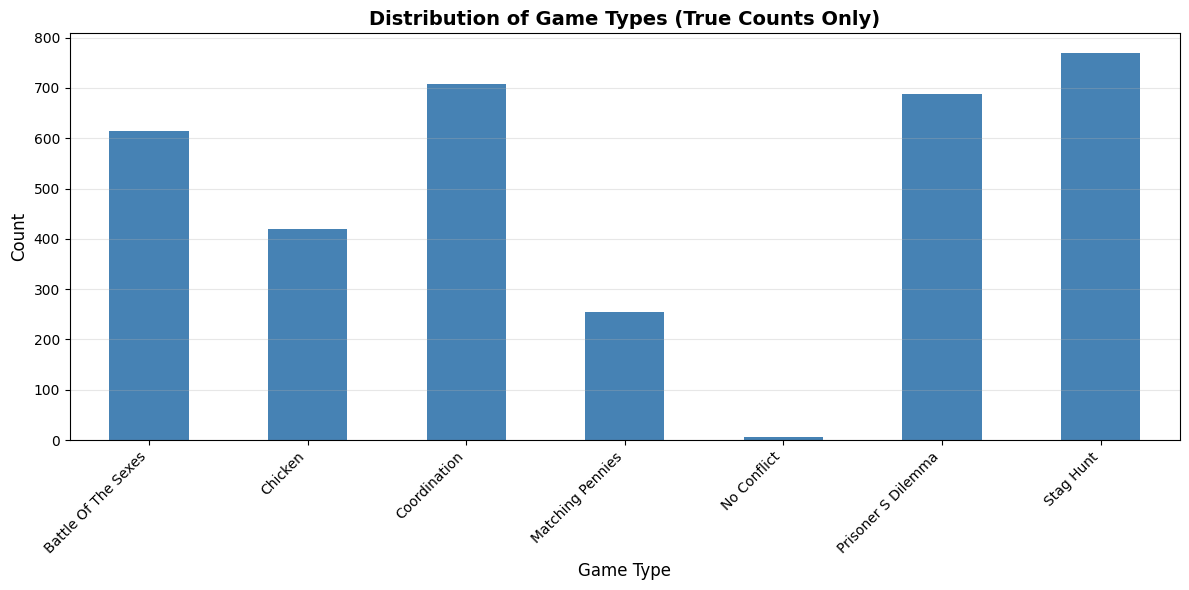

In [8]:
import matplotlib.pyplot as plt

# Get the counts of True values for each game type
true_counts = df2.filter(like='fits').apply(lambda col: col.sum())

# Clean up the column names for better display
true_counts.index = true_counts.index.str.replace('fits_', '').str.replace('_', ' ').str.title()

# Create bar plot
plt.figure(figsize=(12, 6))
true_counts.plot(kind='bar', color='steelblue')
plt.title('Distribution of Game Types (True Counts Only)', fontsize=14, fontweight='bold')
plt.xlabel('Game Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
pprint(df['formal_game'].value_counts())

KeyError: 'formal_game'